In [1]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

In [2]:
import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
#from torch_geometric.data import Batch
#from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from scripts.eval_utils import load_model

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

In [3]:
from hydra.experimental import compose
from hydra import initialize_config_dir

model_path = Path("/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/conf/")

with initialize_config_dir(str(model_path)):
    cfg = compose(config_name = 'default')
    datamodule = hydra.utils.instantiate(
        cfg.data.datamodule, _recursive_=False, scaler_path=None
    )
    datamodule.setup('test')
    test_loader = datamodule.test_dataloader()[0]

loader = test_loader

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20/train_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20/train_20_any.pt
no filter
using 27136 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/tmackey/cdvae/data/mp_20/train_xrd_peak_intensities_dict.pt'
time taken: 15.22132134437561


/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:617: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)


constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20/test_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20/test_20_any.pt
no filter
using 9047 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/tmackey/cdvae/data/mp_20/test_xrd_peak_intensities_dict.pt'
time taken: 4.923867702484131


/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [29]:
import importlib 
import eval_utils
importlib.reload(eval_utils)
model_path = Path("/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag/")
model, test_loader, cfg = load_model(model_path, True, test_set_override = "mp_20")

loader = test_loader

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


overriding data with  mp_20
the noise_sd is: 0.01
the noise_sd is: 0.01
constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20/test_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20/test_20_any.pt
no filter
using 9047 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/tmackey/cdvae/data/mp_20/test_xrd_peak_intensities_dict.pt'
time taken: 4.691285848617554
CrystDataModule(self.datasets={'train': {'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy train', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/train.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30, 'train_fraction': 1}, 'val': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy val', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/val.c

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [240]:
list_of_idxs = []
list_of_batchs = []

for idx, batch in enumerate(loader):
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]

def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    disc_sim_xrd = batch_reserve[4]
    pv_xrd = batch_reserve[5]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch, pv_xrd

batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch, pv_xrd = new_dataloader_batch_processor(batch)

batch = batch.cuda()

In [241]:
batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []

In [242]:
num_evals = 1

In [243]:
model = model.to("cuda:0")

In [244]:
from pymatgen.core.lattice import Lattice
from pymatgen.core.structure import Structure
from pymatgen.io.cif import CifWriter

xrd_int = xrd_int.cuda()
xrd_loc = xrd_loc.cuda()
atom_spec = atom_spec.cuda()
disc_sim_xrd = disc_sim_xrd.cuda()
batch = batch.cuda()
pv_xrd = pv_xrd.cuda()

#pv_xrd = torch.tensor(powder_data_list[i], dtype = torch.float32).cuda().unsqueeze(0).unsqueeze(0)
for eval_idx in range(num_evals):
    _, _, z = model.encode(None, xrd_int, xrd_loc, atom_spec, pv_xrd = pv_xrd)

    ld_kwargs = SimpleNamespace(n_step_each=10,
                                step_lr=1e-4,
                                min_sigma=0,
                                save_traj=False,
                                disable_bar=False)

    gt_atom_types = None
    gt_num_atoms = batch.num_atoms
    gt_atom_spec_torch = atom_spec

    outputs = model.langevin_dynamics(
                    z, ld_kwargs, gt_num_atoms, gt_atom_types, gt_atom_spec_torch)

    # collect sampled crystals in this batch.
    batch_frac_coords.append(outputs['frac_coords'].detach().cpu())
    batch_num_atoms.append(outputs['num_atoms'].detach().cpu())
    batch_atom_types.append(outputs['atom_types'].detach().cpu())
    batch_lengths.append(outputs['lengths'].detach().cpu())
    batch_angles.append(outputs['angles'].detach().cpu())
    if ld_kwargs.save_traj:
        batch_all_frac_coords.append(
            outputs['all_frac_coords'][::down_sample_traj_step].detach().cpu())
        batch_all_atom_types.append(
            outputs['all_atom_types'][::down_sample_traj_step].detach().cpu())

100%|██████████| 50/50 [01:20<00:00,  1.60s/it]


In [254]:
all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []


In [255]:
# collect sampled crystals for this z.
frac_coords.append(torch.stack(batch_frac_coords, dim=0))
num_atoms.append(torch.stack(batch_num_atoms, dim=0))
atom_types.append(torch.stack(batch_atom_types, dim=0))
lengths.append(torch.stack(batch_lengths, dim=0))
angles.append(torch.stack(batch_angles, dim=0))
if ld_kwargs.save_traj:
    all_frac_coords_stack.append(
        torch.stack(batch_all_frac_coords, dim=0))
    all_atom_types_stack.append(
        torch.stack(batch_all_atom_types, dim=0))

In [287]:
index = 4

In [288]:
#test the diffraction loss on the first predicted compound
gt = batch[index]

In [289]:
#NOTE THE INTENSITIES WILL LOOK WRONG IF THE DOMAIN IS SET TOO WIDE WITH TOO FEW STEPS

import diffraction as dc
from math import pi
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator

In [290]:
batch_for_snapping = {
    'angles': gt.angles,
    'lengths': gt.lengths,
    'frac_coords': gt.frac_coords,
    'num_atoms': gt.num_atoms,
    'atom_types': gt.atom_types,
}

In [291]:
batch_for_snapping

{'angles': tensor([[120.,  90.,  90.]], device='cuda:0'),
 'lengths': tensor([[4.0960, 7.5338, 7.5338]], device='cuda:0'),
 'frac_coords': tensor([[1.0000e+00, 1.0000e+00, 4.1307e-01],
         [1.3613e-32, 4.1307e-01, 1.0000e+00],
         [1.9867e-32, 5.8693e-01, 5.8693e-01],
         [5.0000e-01, 1.0000e+00, 7.5718e-01],
         [5.0000e-01, 7.5718e-01, 1.0000e+00],
         [5.0000e-01, 2.4282e-01, 2.4282e-01],
         [5.0000e-01, 6.6667e-01, 3.3333e-01],
         [5.0000e-01, 3.3333e-01, 6.6667e-01],
         [0.0000e+00, 0.0000e+00, 0.0000e+00]], device='cuda:0'),
 'num_atoms': tensor([9], device='cuda:0'),
 'atom_types': tensor([64, 64, 64, 12, 12, 12, 46, 46, 46], device='cuda:0')}

The pattern will be accurate out to: 157.96318411669148


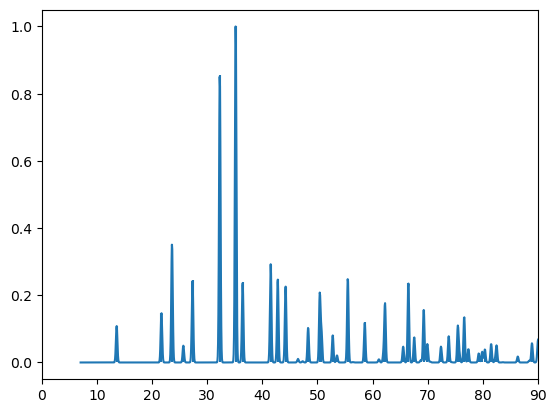

In [292]:
q_max = 8
wavelength = 1.54184
max_two_theta = 90
print("The pattern will be accurate out to:", np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi)

#DC = dc.diffraction_calculator(q_max=10, q_step=0.1, q_width=0.1, wavelength=1.0, device='cpu')
DC = dc.diffraction_pattern(q_max= q_max, wavelength= wavelength)

mini_batch_size = 8
if batch['angles'].size()[0] % mini_batch_size != 0:
    print("set mini_batch_size to be multiplicative factor of the batch size")

pattern = DC.diffraction_calc(batch_for_snapping, indices = [0,8])

pymat_pattern = DC.pymatgen_pattern(pattern[:,0,:])[2:]
pymat_pattern[:,1] = pymat_pattern[:,1]/ torch.max(pymat_pattern[:,1])

scan, domain = DC.bin_pattern_theta(pattern, num_steps = 2560)

xrd_calculator = XRDCalculator(wavelength=wavelength)#, symprec=0.1)

structure = Structure(
    lattice=Lattice.from_parameters(
        *(batch_for_snapping['lengths'][0].tolist() + batch_for_snapping['angles'][0].tolist())),
        species=batch_for_snapping['atom_types'].tolist(), coords=batch_for_snapping['frac_coords'].tolist(), coords_are_cartesian=False)

pymatgen_pattern = xrd_calculator.get_pattern(structure)

plt.plot(domain.cpu().detach().numpy(), scan[0].cpu().detach().numpy() / torch.max(scan[0]).cpu().detach().numpy())
plt.vlines(pymatgen_pattern.x, np.zeros(len(pymatgen_pattern.x)), pymatgen_pattern.y / np.max(pymatgen_pattern.y))
plt.xlim(0,max_two_theta)
plt.show()
plt.close()

In [293]:
pred_num_atoms = batch_num_atoms[0][index]
pred_lengths = batch_lengths[0][index]
pred_angles = batch_angles[0][index] 

In [294]:
cum_sum_num_atoms = np.cumsum(batch_num_atoms[0])

In [295]:
if index == 0: 
    pred_atom_types = batch_atom_types[0][0:cum_sum_num_atoms[index]]
    pred_frac_coord = batch_frac_coords[0][0:cum_sum_num_atoms[index]]
else:
    pred_atom_types = batch_atom_types[0][cum_sum_num_atoms[index-1]:cum_sum_num_atoms[index]]
    pred_frac_coord = batch_frac_coords[0][cum_sum_num_atoms[index-1]:cum_sum_num_atoms[index]]

In [296]:
batch_to_snap = {
    'angles': torch.tensor(pred_angles.unsqueeze(0), requires_grad = True).cuda(),
    'lengths': torch.tensor(pred_lengths.unsqueeze(0), requires_grad = True).cuda(),
    'frac_coords': torch.tensor(pred_frac_coord, requires_grad = True).cuda(),
    'num_atoms': torch.tensor(pred_num_atoms.unsqueeze(0)).cuda(),
    'atom_types': torch.tensor(pred_atom_types).cuda()
}

batch_to_snap['lengths'] = batch_to_snap['lengths'].clone().detach().requires_grad_(True)
batch_to_snap['angles'] = batch_to_snap['angles'].clone().detach().requires_grad_(True)
batch_to_snap['frac_coords'] = batch_to_snap['frac_coords'].clone().detach().requires_grad_(True)
batch_to_snap

/state/partition1/slurm_tmp/24758228.0.0/ipykernel_513653/1082058745.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'angles': torch.tensor(pred_angles.unsqueeze(0), requires_grad = True).cuda(),
/state/partition1/slurm_tmp/24758228.0.0/ipykernel_513653/1082058745.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'lengths': torch.tensor(pred_lengths.unsqueeze(0), requires_grad = True).cuda(),
/state/partition1/slurm_tmp/24758228.0.0/ipykernel_513653/1082058745.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'frac_coords': torch.

{'angles': tensor([[118.7039,  91.3594,  90.7355]], device='cuda:0', requires_grad=True),
 'lengths': tensor([[4.1341, 7.5085, 7.8284]], device='cuda:0', requires_grad=True),
 'frac_coords': tensor([[0.1993, 0.8428, 0.7717],
         [0.2037, 0.0893, 0.5253],
         [0.7122, 0.4981, 0.7666],
         [0.2006, 0.3328, 0.0207],
         [0.7030, 0.0846, 0.1821],
         [0.7019, 0.6807, 0.3587],
         [0.2060, 0.4196, 0.4365],
         [0.7015, 0.0863, 0.7720],
         [0.1972, 0.7500, 0.1036]], device='cuda:0', requires_grad=True),
 'num_atoms': tensor([9], device='cuda:0'),
 'atom_types': tensor([12, 12, 64, 12, 64, 64, 46, 46, 46], device='cuda:0')}

In [297]:
print(DC.snap_structure(scan[0], batch, iterations = 10000, learning_rate = 0.0005, U = 0, V = 0, W = 10, sharpen_rate = 0.0001, plot_progress = True, plot_freq = 200))

"""
max_r = self.q_max / (2 * pi)
max_recip_length = q_max /2pi
two theta = 360 / pi * arcsin(wavelength * recip_length / 2)"""


"""
pattern[1][0][3].backward()
#print(pattern[:,0,:])
#print(batch['angles'][0])
print(batch['angles'].grad)
#print(batch['frac_coords'][0])
print(batch['frac_coords'].grad)
#scan = DC.bin_pattern_theta(pattern)
#print(scan)
#plt.plot(scan)"""

RuntimeError: CUDA out of memory. Tried to allocate 47.81 GiB (GPU 0; 31.74 GiB total capacity; 860.29 MiB already allocated; 29.44 GiB free; 914.00 MiB reserved in total by PyTorch)

In [ ]:
scan[0] = scan[0] + torch.randn(scan.shape).cuda() * 0.01 * torch.max(scan[0])

#"preferred orientation" - actually more aggressive than in real life but a conservative estimate


In [ ]:
input_data_list = input_data_list + batch.to_data_list()

from torch_geometric.data import Batch

input_data_batch = Batch.from_data_list(input_data_list)

recon_out_name = "for_structure_snapping.pt"

model_path_as_str = '/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag'

torch.save({
            'eval_setting': "not relevant here",
            'input_data_batch': input_data_batch,
            'frac_coords': frac_coords,
            'num_atoms': num_atoms,
            'atom_types': atom_types,
            'lengths': lengths,
            'angles': angles,
            'all_frac_coords_stack': all_frac_coords_stack,
            'all_atom_types_stack': all_atom_types_stack,
            'time': 0,
        }, model_path_as_str + recon_out_name)